In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, classification_report, accuracy_score
from lightgbm import LGBMClassifier

mlflow.set_experiment("PBL_Prosper_Loan_Modelling")
print("✅ Cell 1: MLflow Config & Data Prep siap")

# 1. Define Features
cat_cols = ['EmploymentStatus', 'Occupation', 'BorrowerState', 'ProsperRating (Alpha)', 'IncomeRange']
num_cols = [
    'Term', 'ListingCategory (numeric)', 'EmploymentStatusDuration', 'StatedMonthlyIncome',
    'DebtToIncomeRatio', 'IsBorrowerHomeowner', 'IncomeVerifiable', 'CreditScoreRangeLower',
    'CreditScoreRangeUpper', 'ProsperScore', 'ProsperRating (numeric)', 'CurrentCreditLines',
    'OpenCreditLines', 'TotalCreditLinespast7years', 'TotalTrades', 'OpenRevolvingAccounts',
    'OpenRevolvingMonthlyPayment', 'BankcardUtilization', 'AvailableBankcardCredit',
    'RevolvingCreditBalance', 'TradesNeverDelinquent (percentage)', 'CurrentDelinquencies',
    'DelinquenciesLast7Years'
]
features_28 = cat_cols + num_cols

# 2. Load Dataset
df = pd.read_csv(r"D:\Koding Liburan\Full Dataset\prosperloandata_28_fitur_large.csv", low_memory=False)

# Reconstruct categorical columns
if 'EmploymentStatus' not in df.columns:
    emp_cols = [c for c in df.columns if c.startswith("EmploymentStatus_") and c != "EmploymentStatusDuration"]
    df['EmploymentStatus'] = "Other"
    for col in emp_cols:
        df.loc[df[col] == 1, 'EmploymentStatus'] = col.replace("EmploymentStatus_", "")

if 'IncomeRange' not in df.columns:
    inc_cols = [c for c in df.columns if c.startswith("IncomeRange_")]
    df['IncomeRange'] = "$25,000-49,999"
    for col in inc_cols:
        df.loc[df[col] == 1, 'IncomeRange'] = col.replace("IncomeRange_", "")

if 'ProsperRating (Alpha)' not in df.columns:
    rating_map = {1: 'HR', 2: 'E', 3: 'D', 4: 'C', 5: 'B', 6: 'A', 7: 'AA'}
    df['ProsperRating (Alpha)'] = df['ProsperRating (numeric)'].round().fillna(4).map(rating_map).fillna('C')

for col in cat_cols:
    df[col] = df[col].astype(str)

# 3. Map Target Klasifikasi (1 = ACC, 0 = REJECT)
df['LoanApprovalStatus'] = df['LoanStatus'].apply(lambda x: 1 if x in ['Completed', 'Current', 'FinalPaymentInProgress'] else 0)

# 4. Split Train/Val
X_clf = df[features_28]
y_clf = df['LoanApprovalStatus'].values
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 5. Pipeline Preprocessing & Model Baseline
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), 
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_cols)
], remainder='drop')

pipe_klasifikasi = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
])

# 6. Train & Evaluate
with mlflow.start_run(run_name="Klasifikasi_LGBM_Baseline"):
    
    # 1. Training
    print("Training Classification Model...")
    pipe_klasifikasi.fit(X_train_clf, y_train_clf)
    y_proba = pipe_klasifikasi.predict_proba(X_val_clf)[:, 1]

    # best_tresh
    best_thresh, best_f1 = 0.5, 0
    for th in np.arange(0.3, 0.8, 0.01):
        f1 = f1_score(y_val_clf, y_proba >= th)
        if f1 > best_f1:
            best_f1, best_thresh = f1, th


    y_pred_clf = (y_proba >= best_thresh).astype(int)
    
    # 3. MASUKIN METRIK KE MLFLOW (BAGIAN PENTING)
    mlflow.log_metric("accuracy", accuracy_score(y_val_clf, y_pred_clf))
    mlflow.log_metric("f1_score_acc", best_f1)
    
    # 4. SIMPAN MODEL PIPELINE (Artifact)
    mlflow.sklearn.log_model(pipe_klasifikasi, "classifier_model")
    
    print(f"Optimal Threshold: {best_thresh:.4f}")
    print(f"Accuracy: {accuracy_score(y_val_clf, y_pred_clf):.4%}")
    print("\nClassification Report:\n", classification_report(y_val_clf, y_pred_clf, target_names=['REJECT', 'ACC']))

# --- AKHIR CELL 2 ---

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Cell 1: MLflow Config & Data Prep siap
Training Classification Model...


2026/06/06 20:01:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:01:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Optimal Threshold: 0.4900
Accuracy: 84.7244%

Classification Report:
               precision    recall  f1-score   support

      REJECT       0.67      0.19      0.30      3863
         ACC       0.86      0.98      0.91     18925

    accuracy                           0.85     22788
   macro avg       0.76      0.59      0.61     22788
weighted avg       0.82      0.85      0.81     22788



Menghitung Learning Curve Klasifikasi...


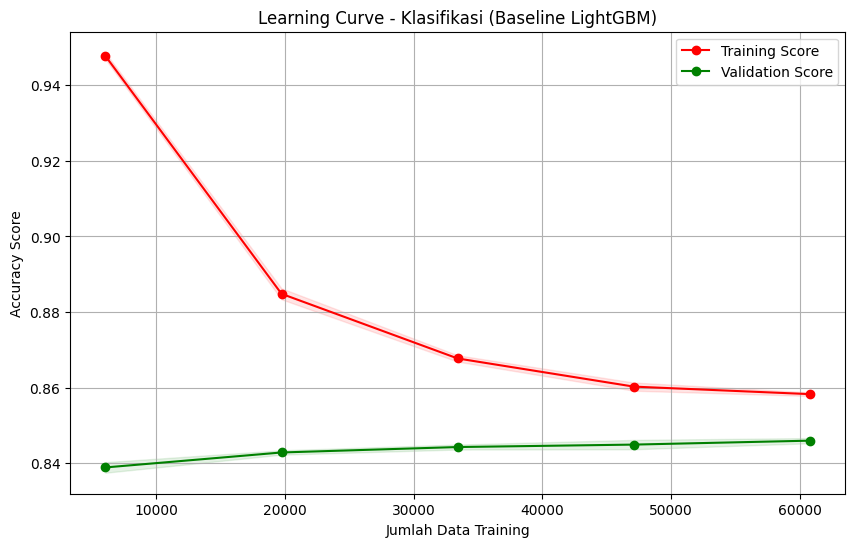

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

print("Menghitung Learning Curve Klasifikasi...")
train_sizes_req = np.linspace(0.1, 1.0, 5)
train_sizes_clf, train_scores_clf, test_scores_clf = learning_curve(
    pipe_klasifikasi, X_train_clf, y_train_clf, 
    cv=3, scoring='accuracy', n_jobs=-1, train_sizes=train_sizes_req
)

train_mean_clf = np.mean(train_scores_clf, axis=1)
train_std_clf = np.std(train_scores_clf, axis=1)
test_mean_clf = np.mean(test_scores_clf, axis=1)
test_std_clf = np.std(test_scores_clf, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Klasifikasi (Baseline LightGBM)")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy Score")
plt.grid()
plt.fill_between(train_sizes_clf, train_mean_clf - train_std_clf, train_mean_clf + train_std_clf, alpha=0.1, color="r")
plt.fill_between(train_sizes_clf, test_mean_clf - test_std_clf, test_mean_clf + test_std_clf, alpha=0.1, color="g")
plt.plot(train_sizes_clf, train_mean_clf, 'o-', color="r", label="Training Score")
plt.plot(train_sizes_clf, test_mean_clf, 'o-', color="g", label="Validation Score")
plt.legend(loc="best")
plt.show()

In [3]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Filter ACC Only (Mencegah Kebocoran Data)
df_acc = df[df['LoanApprovalStatus'] == 1].copy()
df_acc = df_acc.dropna(subset=['LoanOriginalAmount'])

X_reg = df_acc[features_28]
y_reg = df_acc['LoanOriginalAmount'].values
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2. Definisikan 5 Model Baseline (TANPA TUNING)
models = {
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Bayesian Ridge": BayesianRidge()
}

# Cell 3: Komparasi 5 Model Regresi (Baseline)
hasil_evaluasi = []
best_r2 = -float('inf')
best_model_name = ""
best_pipeline_reg = None
best_run_id = None # PENTING: Variabel ini buat ngelink ke Cell 4

print("Melatih 5 Model Regresi (Baseline) & Logging ke MLflow...")

for nama_model, algoritma in models.items():
    print(f"-> Training {nama_model}...")
    
    # BUKA REKAMAN MLFLOW UNTUK TIAP MODEL DI DALAM LOOPING
    with mlflow.start_run(run_name=f"Baseline_{nama_model}") as run:
        pipe_reg = Pipeline([
            ('preprocessor', preprocessor),
            ('model', algoritma)
        ])
        
        # Training
        pipe_reg.fit(X_train_reg, y_train_reg)
        y_pred_reg = pipe_reg.predict(X_val_reg)
        
        # Hitung Metrik
        r2 = r2_score(y_val_reg, y_pred_reg)
        mae = mean_absolute_error(y_val_reg, y_pred_reg)
        rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_reg))
        
        # 1. CATAT PARAMETER & METRIK KE MLFLOW
        mlflow.log_param("algoritma", nama_model)
        mlflow.log_metric("r2_score", r2)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("rmse", rmse)
        
        # 2. SIMPAN MODEL PIPELINE KE MLFLOW (Artifact)
        mlflow.sklearn.log_model(pipe_reg, f"model_{nama_model}")
        
        # Simpan ke list buat display leaderboard
        hasil_evaluasi.append({"Algoritma": nama_model, "R2 Score": r2, "MAE": mae, "RMSE": rmse})
        
        # 3. Update model terbaik untuk Cell 4
        if r2 > best_r2:
            best_r2 = r2
            best_pipeline_reg = pipe_reg
            best_run_id = run.info.run_id # SIMPAN RUN ID-NYA BUAT CELL 4

# Tampilkan Leaderboard
df_hasil = pd.DataFrame(hasil_evaluasi).sort_values(by="R2 Score", ascending=False)
print("\n=== LEADERBOARD REGRESI (BASELINE) ===")
print(df_hasil.to_string(index=False))
print(f"\n✅ Cell 3 Selesai. Model terbaik '{best_pipeline_reg.named_steps['model']}' sudah siap buat Cell 4!")

Melatih 5 Model Regresi (Baseline) & Logging ke MLflow...
-> Training LightGBM...


2026/06/06 20:02:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:02:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


-> Training Random Forest...


2026/06/06 20:02:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:02:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


-> Training Extra Trees...


...

-> Training Gradient Boosting...


2026/06/06 20:03:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:03:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


-> Training Bayesian Ridge...


2026/06/06 20:03:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:03:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== LEADERBOARD REGRESI (BASELINE) ===
        Algoritma  R2 Score         MAE        RMSE
         LightGBM  0.596390 2917.196684 4019.233887
      Extra Trees  0.596073 2876.318061 4020.810705
    Random Forest  0.583551 2918.254729 4082.657356
Gradient Boosting  0.544139 3138.401558 4271.480790
   Bayesian Ridge  0.431833 3590.789185 4768.703730

✅ Cell 3 Selesai. Model terbaik 'LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1)' sudah siap buat Cell 4!


Menghitung Learning Curve Regresi untuk model terbaik ()...


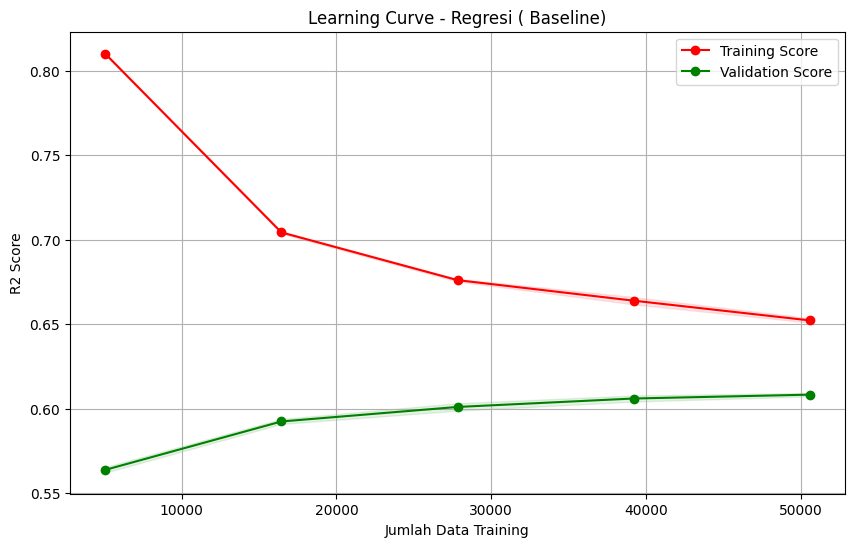

In [4]:
print(f"Menghitung Learning Curve Regresi untuk model terbaik ({best_model_name})...")
train_sizes_reg, train_scores_reg, test_scores_reg = learning_curve(
    best_pipeline_reg, X_train_reg, y_train_reg, 
    cv=3, scoring='r2', n_jobs=-1, train_sizes=train_sizes_req
)

train_mean_reg = np.mean(train_scores_reg, axis=1)
train_std_reg = np.std(train_scores_reg, axis=1)
test_mean_reg = np.mean(test_scores_reg, axis=1)
test_std_reg = np.std(test_scores_reg, axis=1)

plt.figure(figsize=(10, 6))
plt.title(f"Learning Curve - Regresi ({best_model_name} Baseline)")
plt.xlabel("Jumlah Data Training")
plt.ylabel("R2 Score")
plt.grid()
plt.fill_between(train_sizes_reg, train_mean_reg - train_std_reg, train_mean_reg + train_std_reg, alpha=0.1, color="r")
plt.fill_between(train_sizes_reg, test_mean_reg - test_std_reg, test_mean_reg + test_std_reg, alpha=0.1, color="g")
plt.plot(train_sizes_reg, train_mean_reg, 'o-', color="r", label="Training Score")
plt.plot(train_sizes_reg, test_mean_reg, 'o-', color="g", label="Validation Score")
plt.legend(loc="best")
plt.show()

In [5]:
# Cell A: Hyperparameter Tuning
import joblib

print("Memulai Hyperparameter Tuning (Mode Anti-Overfitting)...")

# 1. Parameter Grid
param_dist = {
    'model__n_estimators': [100, 200, 300], 
    'model__learning_rate': [0.01, 0.05], 
    'model__max_depth': [3, 4, 5], 
    'model__num_leaves': [10, 15, 31], 
    'model__min_child_samples': [30, 50, 100], 
    'model__subsample': [0.6, 0.8], 
    'model__colsample_bytree': [0.6, 0.8], 
    'model__reg_alpha': [0.1, 1.0, 5.0, 10.0], 
    'model__reg_lambda': [0.1, 1.0, 5.0, 10.0] 
}

# 2. Setup & Eksekusi RandomizedSearchCV di MLflow
with mlflow.start_run(run_name="Regresi_Tuned_LGBM"):
    random_search = RandomizedSearchCV(
        best_pipeline_reg, 
        param_distributions=param_dist, 
        n_iter=40, 
        cv=3, 
        scoring='r2', 
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    random_search.fit(X_train_reg, y_train_reg)
    
    # 3. Evaluasi & Logging
    best_lgbm_tuned = random_search.best_estimator_
    y_pred_tuned = best_lgbm_tuned.predict(X_val_reg)
    
    r2_new = r2_score(y_val_reg, y_pred_tuned)
    mae_new = mean_absolute_error(y_val_reg, y_pred_tuned)
    rmse_new = np.sqrt(mean_squared_error(y_val_reg, y_pred_tuned))
    
    # Log ke MLflow
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metrics({"r2_tuned": r2_new, "mae_tuned": mae_new, "rmse_tuned": rmse_new})
    mlflow.sklearn.log_model(best_lgbm_tuned, "tuned_regressor")
    
    print(f"\n✅ Tuning Selesai! R2 Score Baru: {r2_new:.4f}, MAE Baru: {mae_new:.4f}, RMSE Baru: {rmse_new:.4f}")
    joblib.dump(best_lgbm_tuned, "model_regresi_tuned_final.pkl")

Memulai Hyperparameter Tuning (Mode Anti-Overfitting)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits


2026/06/06 20:04:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:04:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ Tuning Selesai! R2 Score Baru: 0.5828, MAE Baru: 2973.6892, RMSE Baru: 4086.2518


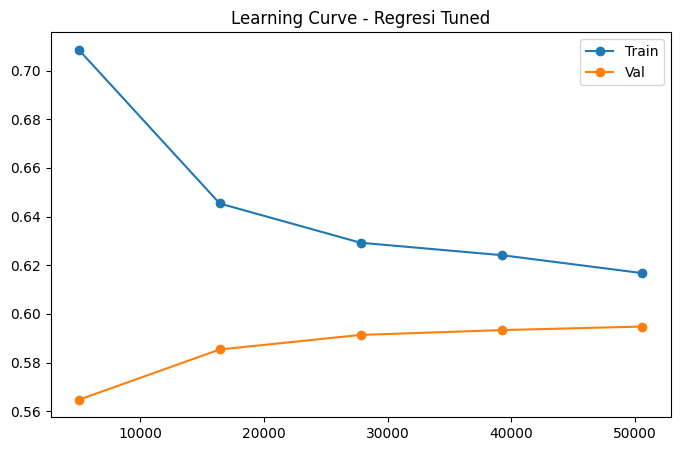

✅ Learning Curve Tuned ditampilkan.


In [6]:
# 4. Evaluasi Model Baru
best_lgbm_tuned = random_search.best_estimator_
y_pred_tuned = best_lgbm_tuned.predict(X_val_reg)
train_sizes_tune, train_scores_tune, test_scores_tune = learning_curve(best_lgbm_tuned, X_train_reg, y_train_reg, cv=3, scoring='r2', n_jobs=-1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_tune, np.mean(train_scores_tune, axis=1), 'o-', label="Train")
plt.plot(train_sizes_tune, np.mean(test_scores_tune, axis=1), 'o-', label="Val")
plt.title("Learning Curve - Regresi Tuned")
plt.legend(); plt.show()
print("✅ Learning Curve Tuned ditampilkan.")

In [7]:
import joblib

# 1. Simpan Model Klasifikasi (Pipeline utuh dari prep sampe model)
joblib.dump(pipe_klasifikasi, "model_klasifikasi_loan.pkl")
print("✅ Model Klasifikasi berhasil di-pickle dan disave!")

# 2. Simpan Model Regresi (Hasil Tuning lu yang paling mantap)
joblib.dump(best_lgbm_tuned, "model_regresi_tuned_loan.pkl")
print("✅ Model Regresi berhasil di-pickle dan disave!")

✅ Model Klasifikasi berhasil di-pickle dan disave!
✅ Model Regresi berhasil di-pickle dan disave!
